In [59]:
import sys
import copy
import time
import rospy

import numpy as np
from final_header import *
from final_func import *
import cv2 as cv
from matplotlib import pyplot as plt
import os

956

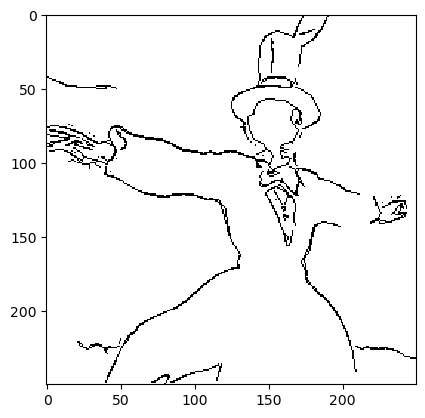

In [80]:
def find_keypoints(image):
    """Gets keypoints from the given image

    Parameters
    ----------
    image : np.ndarray
        The given image (before or after preprocessing)

    Returns
    -------
    keypoints
        a list of keypoints detected in image coordinates
    """
    im = cv.imread(image)
    im = cv.resize(im, (250,250))
    assert im is not None, "file could not be read, check with os.path.exists()"

    edges = cv.Canny(im,100,200)
    ret, thresh = cv.threshold(edges, 127, 255, 0)
    im2 = contours, hierarchy = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    canvas = np.zeros_like(edges) + 1

    length = []
    dList0 = []
    for i in range(len(contours)):
        length.append(len(contours[i]))
        # if len(contours[i]) < 15:
        #     dList0.append(contours[i])
            
    # contours = list(contours)
    # for i in range(len(dList0)):
    #     contours.remove(dList0[i])
    # contours = tuple(contours)

    long15 = []
    for i in range(len(contours)//1):
        long = max(length)
        longIndex = length.index(long)
        long15.append(longIndex)
        length[longIndex] = 0

        every = 2
        contours = list(contours)
        dList = np.arange(0,len(contours[longIndex]),every)
        dList2 = np.arange(0,len(contours[longIndex]),1)
        dList3 = np.delete(dList2, dList)
        contours[longIndex] = np.delete(contours[longIndex],dList3, axis=0)
        contours = tuple(contours)
        
    points = []
    for i in range(len(long15)):
        cv.drawContours(canvas, contours, long15[i], (0,255,0), 1)
        points.append(len(contours[long15[i]]))

    totalPoints = np.sum(np.array(points))
    plt.imshow(canvas, cmap='gray')
    return canvas, contours, totalPoints

find_keypoints('images/turnipHead.jpeg')[2]

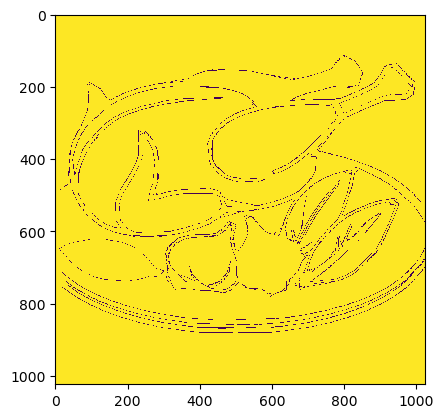

In [ ]:
cont = find_keypoints('images/turkey.png')[1]
    
# for i in range(len(cont)):
#     pointList = cont[i]
#     for j in range(len(pointList)):
#         print(j)
#         destination = lab_invk(pointList[j][0], pointList[j][1], 0.025, 0)
